# End-to-End Evaluation on BLOOM-FaaS

Measured runs of optimized plans on the Grid'5000 testbed (TPC-H SF100, BLOOM-FaaS with Bloom filters, S3 shuffle).
`data/e2e-runs.csv` has one row per run: measured query time `T_s` and cost `C_usd` (resources used, priced with
AWS list prices).

* **`sweep`** (Q3, Q9, Q18; 3 runs per plan): per-stage `max_size_mb` chosen from the measured size sweep —
  `default` (every stage 50 MB), `best_global` (one size for all stages, the fastest one of the sweep), `knee`
  (balanced), `min_T` (minimum time), `min_C` (minimum cost). Estimates in `sweep-plans.csv`.
* **`s3opt`** (19 queries; 3 runs per scenario): functions running at once limited after the MinIO
  characterisation (`s3opt-scenarios.json`) — `default` (every stage max_parallel 70, 50 MB), `scan_mp20` (scans
  max_parallel 20), `scan_opt` (scans max_parallel 20 and 70 MB), `all_mp20` (every stage max_parallel 20).
* **`validate`** (19 queries; 3 runs per plan): plans of the optimizer on the cost model's Pareto front —
  `default` (every Bloom filter on, 50 MB), `knee` (balanced), `min_T`, `min_C` and intermediate points `front_02`…
  `front_05`. Estimates in `validate-plans.csv`; a plan that is the same as another one of its query (e.g. Q17
  `min_T` = `knee`) is listed in `validate-aliases.csv` and was run once.
* **`baseline`**: BLOOM-FaaS without Bloom filters (`no_bf`, 15 runs per query, from the accuracy runs).

Noise: two identical configurations measured in different sessions differed by about 6% in time and up to 20% in
cost with 3 runs, so differences below that are not significant.

In [62]:
import os, sys, json
sys.path.insert(0, os.path.abspath(".."))      # repository root: cofi/style.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cofi import style
%matplotlib inline
style.apply()
FONT_SIZE = style.FONT_SIZE
DATA, FIG = "data", "figures"
os.makedirs(FIG, exist_ok=True)
pd.set_option("display.width", 160)
qnum = lambda q: int("".join(c for c in q if c.isdigit()) or 0)

import glob
R = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(f"{DATA}/e2e-runs*.csv"))], ignore_index=True)   # e2e-runs-<experiment>.csv added later are read too
EST = pd.read_csv(f"{DATA}/sweep-plans.csv")
R["C"] = R["C_usd"] * style.COST_SCALE
ALIAS = pd.read_csv(f"{DATA}/validate-aliases.csv")      # plan run once when it equals another plan of the query
_v = R[R.experiment == "validate"]
R = pd.concat([R] + [_v[(_v["query"] == a.query) & (_v.plan == a.same_as)].assign(plan=a.plan)
                     for a in ALIAS.itertuples()
                     if not ((_v["query"] == a.query) & (_v.plan == a.plan)).any()], ignore_index=True)
MED = R.groupby(["experiment", "query", "plan"]).agg(runs=("T_s", "size"), T=("T_s", "median"), T_lo=("T_s", "min"),
        T_hi=("T_s", "max"), C=("C", "median"), C_lo=("C", "min"), C_hi=("C", "max")).reset_index()
R.groupby(["experiment", "plan"]).size().rename("runs").to_frame().T

experiment baseline    s3opt                                  sweep                          validate                                                        \
plan          no_bf all_mp20 default scan_mp20 scan_opt best_global default knee min_C min_T  default front_01 front_02 front_03 front_04 front_05 front_06   
runs            285       57      57        57       57           9       9    9     9     9       60       60       57       57       54       54       51   

experiment                   
plan       knee min_C min_T  
runs         60    54    60

## Final results: total time and cost over the queries

The first chart puts each system at its (total time, total cost): left is faster, lower is cheaper, and the\ndashed lines go through BLOOM-FaaS with Bloom filters always on, so a point in the shaded corner is both faster and\ncheaper than it. The two bar charts after it give the same totals one metric at a time.\n\nFive systems, summed over the queries where all five were measured (median of the runs of each query):
BLOOM-FaaS without Bloom filters, BLOOM-FaaS with every Bloom filter on (default plan, 50 MB), and the plans
chosen by the optimizer: the balanced plan (opti = knee), the minimum-time and the minimum-cost plan. Error bars:
sum of the per-query min / max over runs. The percentage above each bar is the change against BLOOM-FaaS with
Bloom filters always on.

Uses the 19-query validation experiment (`validate`) when its runs are in `data/`, then `grid`, otherwise the
Q3 / Q9 / Q18 sweep experiment. The non-BF runs are those of the same experiment when it has them (`no_bf` plan), otherwise the accuracy
campaign's (an earlier session than the plan runs).

In [63]:
E2E_SET = next(e for e in ("validate", "grid", "sweep") if (R.experiment == e).any())
same_session = ((R.experiment == E2E_SET) & (R.plan == "no_bf")).any()   # non-BF runs of the same session, if any
SYSTEMS = [(E2E_SET if same_session else "baseline", "no_bf", "BLOOM-FaaS non-BF", "#8a8983"),
           (E2E_SET, "default", "BLOOM-FaaS BF always on", "#52514e"),
           (E2E_SET, "knee", "BLOOM-FaaS opti", "#2a78d6"),
           (E2E_SET, "min_T", "BLOOM-FaaS min-T", "#eb6834"),
           (E2E_SET, "min_C", "BLOOM-FaaS min-C", "#1baf7a")]
have = [set(MED[(MED.experiment == e) & (MED.plan == p)]["query"]) for e, p, _, _ in SYSTEMS]
QS_E2E = sorted(set.intersection(*have), key=qnum)
TOT = pd.DataFrame([{"system": lab, "color": col,
                     **{k: MED[(MED.experiment == e) & (MED.plan == p) & MED["query"].isin(QS_E2E)][k].sum()
                        for k in ("T", "T_lo", "T_hi", "C", "C_lo", "C_hi")}}
                    for e, p, lab, col in SYSTEMS]).set_index("system")
# reference of the percentages in the table and the charts below:
#   "BLOOM-FaaS BF always on" (what the optimizer adds on top of Bloom filters) or "BLOOM-FaaS non-BF"
REF = "BLOOM-FaaS BF always on"
NOBF = "BLOOM-FaaS non-BF"
REF_SHORT = REF.replace("BLOOM-FaaS ", "")
REF_SUFFIX = "" if REF != NOBF else "-vs-nobf"     # figures with the non-BF reference are saved next to the others
TOT[f"ΔT vs {REF_SHORT}"] = (TOT["T"] / TOT.loc[REF, "T"] - 1).map("{:+.0%}".format)
TOT[f"ΔC vs {REF_SHORT}"] = (TOT["C"] / TOT.loc[REF, "C"] - 1).map("{:+.0%}".format)
print(f"experiment: {E2E_SET}, {len(QS_E2E)} queries: {', '.join(q.upper() for q in QS_E2E)}")
print("left out (a system not measured):", ", ".join(q.upper() for q in sorted(set.union(*have) - set(QS_E2E), key=qnum)) or "-")
TOT.drop(columns="color").round(2)

experiment: validate, 19 queries: Q2, Q3, Q4, Q5, Q7, Q8, Q9, Q10, Q11, Q12, Q13, Q14, Q15, Q16, Q17, Q18, Q19, Q20, Q21
left out (a system not measured): -


,T,T_lo,T_hi,C,C_lo,C_hi,ΔT vs BF always on,ΔC vs BF always on
system,,,,,,,,
BLOOM-FaaS non-BF,550.06,524.85,577.65,160.51,155.04,167.22,+79%,+198%
BLOOM-FaaS BF always on,306.91,302.55,315.05,53.85,52.67,55.14,+0%,+0%
BLOOM-FaaS opti,300.32,288.22,314.94,47.96,47.34,48.49,-2%,-11%
BLOOM-FaaS min-T,311.68,303.72,334.06,62.03,61.35,62.95,+2%,+15%
BLOOM-FaaS min-C,368.95,363.84,383.40,42.60,41.16,43.08,+20%,-21%


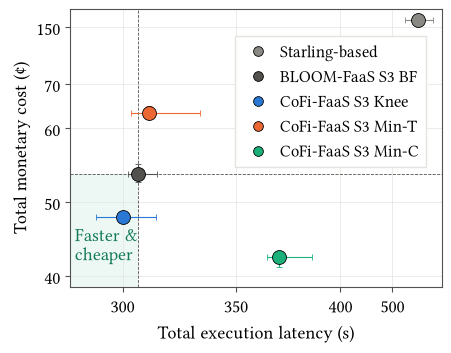

In [64]:
from matplotlib.lines import Line2D
# one chart: each system is a point (total time, total cost); the dashed lines go through the reference (REF), the
# shaded corner = faster and cheaper than it. Both axes are piecewise linear: each range of values gets its own share
# of the axis, so the BF systems (close together) are spread out and the gap up to non-BF is compressed.
#   X_SCALE / Y_SCALE: breakpoints (values) and the share of the axis length between two breakpoints;
#   None = from the data (BF systems on SHARE_BF of the axis, the rest up to non-BF on the remainder)
X_SCALE = None             # e.g. dict(knots=[280, 400, 590], shares=[0.75, 0.25])
Y_SCALE = None             # e.g. dict(knots=[20, 70, 180], shares=[0.70, 0.30])
SHARE_BF = 0.72
X_TICKS = None             # None = a few per range; or a list of values
Y_TICKS = None
# names shown in the legend
DISPLAY_NAME = {"BLOOM-FaaS non-BF": "Starling-based", "BLOOM-FaaS BF always on": "BLOOM-FaaS S3 BF",
                "BLOOM-FaaS opti": "CoFi-FaaS S3 Knee", "BLOOM-FaaS min-T": "CoFi-FaaS S3 Min-T",
                "BLOOM-FaaS min-C": "CoFi-FaaS S3 Min-C"}
# legend position (x, y in axes fraction, loc = the corner of the legend placed at (x, y))
LEGEND_POS = dict(x=0.5, y=1.02, loc="lower center", ncol=2, fontsize=FONT_SIZE - 4)


def piecewise(knots, shares):
    """Forward / inverse functions of a piecewise-linear axis scale: knots[i] -> cumulative share."""
    pos = np.concatenate([[0], np.cumsum(shares)])
    fwd = lambda v: np.interp(v, knots, pos, left=np.nan, right=np.nan)
    inv = lambda p: np.interp(p, pos, knots)
    # extrapolate linearly outside the knots (matplotlib asks for a little beyond the limits)
    f = lambda v: np.where(np.asarray(v) < knots[0], (np.asarray(v) - knots[0]) / (knots[1] - knots[0]) * pos[1],
                  np.where(np.asarray(v) > knots[-1], pos[-1] + (np.asarray(v) - knots[-1]) / (knots[-1] - knots[-2]) * (pos[-1] - pos[-2]),
                           np.interp(v, knots, pos)))
    g = lambda p: np.where(np.asarray(p) < 0, knots[0] + np.asarray(p) / pos[1] * (knots[1] - knots[0]),
                  np.where(np.asarray(p) > pos[-1], knots[-1] + (np.asarray(p) - pos[-1]) / (pos[-1] - pos[-2]) * (knots[-1] - knots[-2]),
                           np.interp(p, pos, knots)))
    return f, g


def auto_scale(lo_key, hi_key, val_key):
    """Knots: below the BF systems, just above them, just above non-BF."""
    bf, nb_ = TOT.drop(index=NOBF), TOT.loc[NOBF]
    lo, hi = bf[lo_key].min(), bf[hi_key].max()
    pad = (hi - lo) * 0.12
    top = nb_[hi_key] + (nb_[hi_key] - lo) * 0.06
    return dict(knots=[lo - pad, hi + pad, top], shares=[SHARE_BF, 1 - SHARE_BF])


def nice_ticks(scale, n=(4, 2), min_gap=0.08):
    """A few round ticks per range; a tick closer than min_gap (axis fraction) to the previous one is dropped."""
    knots = scale["knots"]
    fwd = piecewise(knots, scale["shares"])[0]
    out = []
    for (a, b), k in zip(zip(knots[:-1], knots[1:]), n):
        out += list(plt.MaxNLocator(nbins=k, steps=[1, 2, 2.5, 5, 10]).tick_values(a, b))
    keep = []
    for t in sorted({t for t in out if knots[0] <= t <= knots[-1]}):
        if not keep or fwd(t) - fwd(keep[-1]) >= min_gap * sum(scale["shares"]):
            keep.append(t)
    return keep


def tradeoff_chart(name):
    FONT_SIZE = 13
    ref = TOT.loc[REF]
    xs = X_SCALE or auto_scale("T_lo", "T_hi", "T")
    ys = Y_SCALE or auto_scale("C_lo", "C_hi", "C")
    fig, ax = plt.subplots(figsize=(4.8, 3.6))
    ax.set_xscale("function", functions=piecewise(xs["knots"], xs["shares"]))
    ax.set_yscale("function", functions=piecewise(ys["knots"], ys["shares"]))
    ax.set_xlim(xs["knots"][0], xs["knots"][-1]); ax.set_ylim(ys["knots"][0], ys["knots"][-1])
    ax.set_xticks(X_TICKS or nice_ticks(xs)); ax.set_yticks(Y_TICKS or nice_ticks(ys))
    ax.xaxis.set_minor_locator(plt.NullLocator()); ax.yaxis.set_minor_locator(plt.NullLocator())
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.grid(True, color=style.GRID); ax.set_axisbelow(True)

    ax.fill_between([xs["knots"][0], ref["T"]], ys["knots"][0], ref["C"], color="#1baf7a", alpha=0.08, lw=0, zorder=0)
    ax.text(xs["knots"][0], ys["knots"][0], " Faster &\n cheaper\n", ha="left", va="bottom", fontsize=FONT_SIZE,
            color="#127a55", linespacing=1.0)
    ax.axvline(ref["T"], color=style.INK2, lw=0.6, ls="--", zorder=1); ax.axhline(ref["C"], color=style.INK2, lw=0.6, ls="--", zorder=1)
    handles, names = [], []
    for lab, r in TOT.iterrows():
        ax.errorbar(r["T"], r["C"], xerr=[[r["T"] - r["T_lo"]], [r["T_hi"] - r["T"]]], yerr=[[r["C"] - r["C_lo"]], [r["C_hi"] - r["C"]]],
                    fmt="o", ms=10, color=r["color"], mec="black", mew=0.6, ecolor=r["color"], elinewidth=0.8, capsize=2, zorder=3)

        short = DISPLAY_NAME.get(lab, lab.replace("BLOOM-FaaS ", ""))
        rel = "reference" if lab == REF else \
            f"{r['T'] / ref['T'] - 1:+.0%} time, {r['C'] / ref['C'] - 1:+.0%} cost".replace("-", "−")
        handles.append(Line2D([], [], ls="", marker="o", ms=7, mfc=r["color"], mec="black", mew=0.6))
        names.append(f"{short}")
    lp = dict(LEGEND_POS)

    ax.legend(handles, names, loc=lp.pop("loc"), ncol=1, bbox_to_anchor=(0.7, 0.4), frameon=True, fancybox=False,
              fontsize=FONT_SIZE - 1, edgecolor=style.GRID, framealpha=1, handletextpad=0.3, borderpad=0.4, labelspacing=0.35)

    ax.set_xlabel(f"Total execution latency (s)")
    ax.set_ylabel(f"Total monetary cost ({style.COST_UNIT})")
    style.save(fig, FIG, name)
    plt.show()


tradeoff_chart("e2e-total-tradeoff" + REF_SUFFIX)

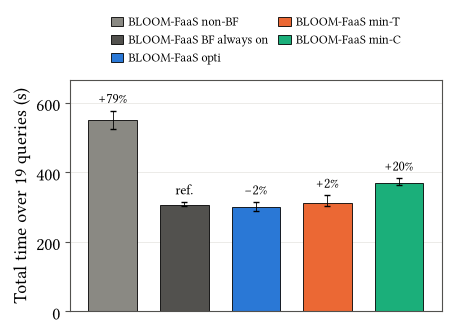

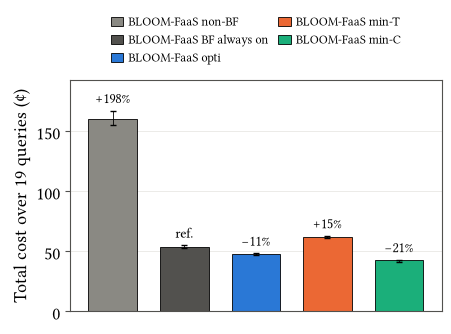

In [65]:
FIGSIZE = (4.8, 3.0)


def total_chart(key, ylabel, name):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    x = np.arange(len(TOT))
    v, lo, hi = TOT[key].to_numpy(), TOT[f"{key}_lo"].to_numpy(), TOT[f"{key}_hi"].to_numpy()
    bars = ax.bar(x, v, 0.68, color=TOT["color"], edgecolor="black", lw=0.6,
                  yerr=[v - lo, hi - v], error_kw={"elinewidth": 0.6, "capsize": 2, "ecolor": "black"}, zorder=2)
    ref = TOT.loc[REF, key]
    for b, val, top in zip(bars, v, hi):
        txt = "ref." if np.isclose(val, ref) else f"{val / ref - 1:+.0%}".replace("-", "−")
        ax.annotate(txt, (b.get_x() + b.get_width() / 2, top), xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=FONT_SIZE - 3)
    ax.set_xticks([])
    ax.set_xlim(-0.6, len(TOT) - 0.4)
    ax.set_ylim(0, hi.max() * 1.15)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", color=style.GRID); ax.grid(False, axis="x"); ax.set_axisbelow(True)
    ax.legend(bars, TOT.index, ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False,
              fontsize=FONT_SIZE - 4, handlelength=1.0, handletextpad=0.4, columnspacing=0.8, labelspacing=0.3)
    style.save(fig, FIG, name)
    plt.show()


total_chart("T", f"Total time over {len(QS_E2E)} queries (s)", "e2e-total-time" + REF_SUFFIX)
total_chart("C", f"Total cost over {len(QS_E2E)} queries ({style.COST_UNIT})", "e2e-total-cost" + REF_SUFFIX)

## Per-stage sizes from the sweep (Q3, Q9, Q18): measured vs. estimated

In [66]:
PLAN_ORDER = ["default", "knee", "min_T", "min_C"]
PLAN_LABEL = {"default": "BLOOM-FaaS S3 BF", "knee": "CoFi-FaaS S3 Knee",
              "min_T": "CoFi-FaaS S3 Min-T", "min_C": "CoFi-FaaS S3 Min-C", "no_bf": "Starling-based"}
PLAN_COLOR = {"default": "#52514e", "best_global": "#c98a00", "knee": "#2a78d6", "min_T": "#eb6834", "min_C": "#1baf7a"}
S = MED[MED.experiment == "sweep"]
qs = sorted(S["query"].unique(), key=qnum)
rows = []
for q in qs:
    d = S[(S["query"] == q) & (S.plan == "default")].iloc[0]
    for p in PLAN_ORDER:
        r = S[(S["query"] == q) & (S.plan == p)].iloc[0]
        e = EST[(EST["query"] == q) & (EST.plan == p)].iloc[0]
        rows.append({"query": q.upper(), "plan": PLAN_LABEL[p], "T meas (s)": r["T"], "T est (s)": e.T_est_s,
                     "err T": f"{e.T_est_s / r['T'] - 1:+.0%}", "speedup": f"{d['T'] / r['T']:.2f}x",
                     f"C meas ({style.COST_UNIT})": r["C"], "saving": f"{1 - r['C'] / d['C']:+.0%}"})
pd.DataFrame(rows).set_index(["query", "plan"]).round(2)

T meas (s)  T est (s) err T speedup  C meas (¢) saving
query plan                                                                      
Q3    BLOOM-FaaS S3 BF         15.96      14.88   -7%   1.00x        1.77    +0%
      CoFi-FaaS S3 Knee        12.69      11.45  -10%   1.26x        1.60   +10%
      CoFi-FaaS S3 Min-T       11.67      10.25  -12%   1.37x        2.29   -29%
      CoFi-FaaS S3 Min-C       21.68      19.98   -8%   0.74x        1.06   +40%
Q9    BLOOM-FaaS S3 BF         26.60      28.34   +7%   1.00x        5.87    +0%
      CoFi-FaaS S3 Knee        26.99      26.71   -1%   0.99x        4.34   +26%
      CoFi-FaaS S3 Min-T       26.94      24.64   -9%   0.99x        5.11   +13%
      CoFi-FaaS S3 Min-C       45.39      43.81   -3%   0.59x        4.13   +30%
Q18   BLOOM-FaaS S3 BF         13.19      12.68   -4%   1.00x        1.93    +0%
      CoFi-FaaS S3 Knee        12.81      11.36  -11%   1.03x        1.41   +27%
      CoFi-FaaS S3 Min-T       11.66      10.77   -8%   1.13x        1.94    -0%
      CoFi-FaaS S3 Min-C       15.03      15.54   +3%   0.88x        1.39   +28%

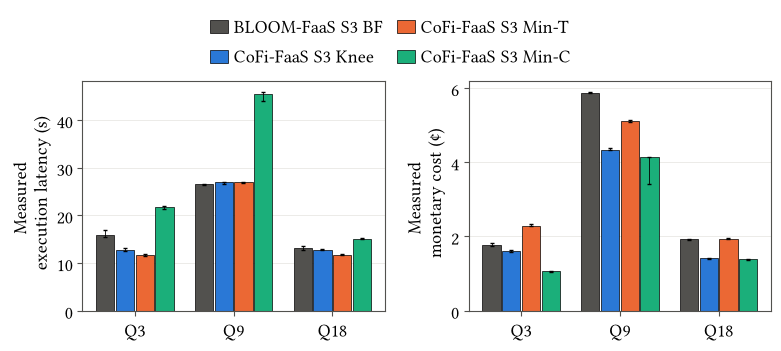

In [67]:
def grouped(ax, data, qs, plans, key, ylabel):
    w = 0.8 / len(plans)
    for i, p in enumerate(plans):
        sub = data.set_index(["query", "plan"])
        xs = np.arange(len(qs)) + (i - (len(plans) - 1) / 2) * w
        v = np.array([sub.loc[(q, p), key] for q in qs])
        lo = np.array([sub.loc[(q, p), f"{key}_lo"] for q in qs]); hi = np.array([sub.loc[(q, p), f"{key}_hi"] for q in qs])
        ax.bar(xs, v, w * 0.92, color=PLAN_COLOR[p], edgecolor="black", lw=0.5, label=PLAN_LABEL[p],
               yerr=[v - lo, hi - v], error_kw={"elinewidth": 0.6, "capsize": 1.5, "ecolor": "black"}, zorder=2)
    ax.set_xticks(range(len(qs)), [q.upper() for q in qs])
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", color=style.GRID); ax.grid(False, axis="x"); ax.set_axisbelow(True)


fig, axs = plt.subplots(1, 2, figsize=(8, 3))
grouped(axs[0], S, qs, PLAN_ORDER, "T", "Measured \n execution latency (s)")
grouped(axs[1], S, qs, PLAN_ORDER, "C", f"Measured \n monetary cost ({style.COST_UNIT})")
h, l = axs[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.2), fontsize=FONT_SIZE, handlelength=1.0, handletextpad=0.3, columnspacing=0.8)
fig.tight_layout()
style.save(fig, FIG, "e2e-sweep-plans")
plt.show()

## Limiting concurrent functions (19 queries): speedup and saving vs. the default plan

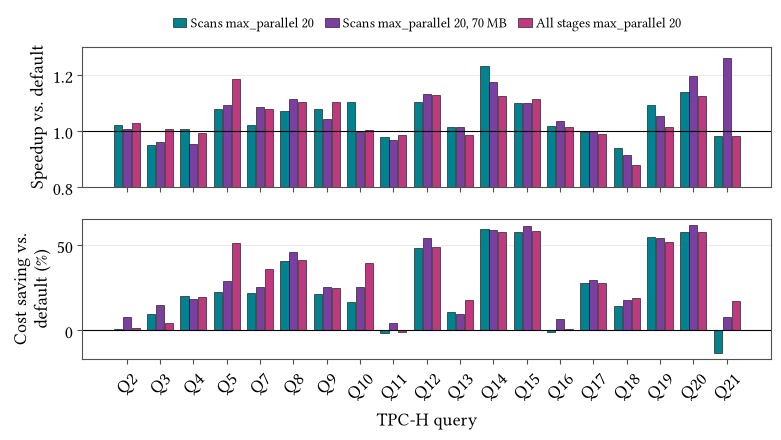

In [68]:
SC_ORDER = ["scan_mp20", "scan_opt", "all_mp20"]
SC_LABEL = {"scan_mp20": "Scans max_parallel 20", "scan_opt": "Scans max_parallel 20, 70 MB", "all_mp20": "All stages max_parallel 20"}
SC_COLOR = {"scan_mp20": "#00838f", "scan_opt": "#7b3fa0", "all_mp20": "#c0397f"}
O = MED[MED.experiment == "s3opt"].set_index(["query", "plan"])
qs = sorted(O.index.get_level_values(0).unique(), key=qnum)
fig, axs = plt.subplots(2, 1, figsize=(8, 4.6), sharex=True)
w = 0.8 / len(SC_ORDER)
for i, sc in enumerate(SC_ORDER):
    xs = np.arange(len(qs)) + (i - (len(SC_ORDER) - 1) / 2) * w
    sp = [O.loc[(q, "default"), "T"] / O.loc[(q, sc), "T"] for q in qs]
    sv = [100 * (1 - O.loc[(q, sc), "C"] / O.loc[(q, "default"), "C"]) for q in qs]
    axs[0].bar(xs, sp, w * 0.92, color=SC_COLOR[sc], edgecolor="black", lw=0.4, label=SC_LABEL[sc], zorder=2)
    axs[1].bar(xs, sv, w * 0.92, color=SC_COLOR[sc], edgecolor="black", lw=0.4, zorder=2)
axs[0].axhline(1, color="black", lw=0.8); axs[1].axhline(0, color="black", lw=0.8)
axs[0].set_ylim(0.8, 1.3)                         # zoom around 1.0: differences of 5-25%
axs[0].set_ylabel("Speedup vs. default"); axs[1].set_ylabel("Cost saving vs.\ndefault (%)")
axs[1].set_xticks(range(len(qs)), [q.upper() for q in qs], rotation=45)
axs[1].set_xlabel("TPC-H query")
for ax in axs:
    ax.grid(True, axis="y", color=style.GRID); ax.grid(False, axis="x"); ax.set_axisbelow(True)
axs[0].legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=FONT_SIZE - 3,
              handlelength=1.0, handletextpad=0.3, columnspacing=0.8)
fig.tight_layout()
style.save(fig, FIG, "e2e-s3opt-scenarios")
plt.show()

In [69]:
# totals over the 19 queries, and the no-BF baseline
B = MED[MED.experiment == "baseline"].set_index("query")
rows = []
for p in ["default"] + SC_ORDER:
    sub = O.xs(p, level="plan")
    sp = (O.xs("default", level="plan")["T"] / sub["T"])
    rows.append({"plan": p, "total T (s)": sub["T"].sum(), f"total C ({style.COST_UNIT})": sub["C"].sum(),
                 "geomean speedup": np.exp(np.log(sp).mean()),
                 "median saving": f"{np.median(100 * (1 - sub['C'] / O.xs('default', level='plan')['C'])):.0f}%",
                 "queries faster >5%": int((sp > 1.05).sum()), "queries slower >5%": int((sp < 0.95).sum())})
rows.append({"plan": "no_bf (baseline)", "total T (s)": B.loc[qs, "T"].sum(), f"total C ({style.COST_UNIT})": B.loc[qs, "C"].sum(),
             "geomean speedup": np.exp(np.log(O.xs("default", level="plan").loc[qs, "T"] / B.loc[qs, "T"]).mean())})
pd.DataFrame(rows).set_index("plan").round(2)

,total T (s),total C (¢),geomean speedup,median saving,queries faster >5%,queries slower >5%
plan,,,,,,
default,311.49,51.07,1.00,0%,0.0,0.0
scan_mp20,299.13,41.84,1.05,21%,9.0,1.0
scan_opt,288.58,37.74,1.05,26%,9.0,1.0
all_mp20,298.60,33.80,1.04,28%,8.0,1.0
no_bf (baseline),550.06,160.51,0.67,NaN,NaN,NaN


## Validation (19 queries): optimized plans vs. the default plan, measured vs. estimated

Per query, median of the runs of `knee`, `min_T` and `min_C` against `default` (every Bloom filter on, 50 MB):
speedup = T_default / T_plan, saving = 1 − C_plan / C_default. The estimate error is T_est / T_meas − 1 (resp. C).

In [70]:
VEST = pd.read_csv(f"{DATA}/validate-plans.csv")
VEST["C_est"] = VEST["C_est_usd"] * style.COST_SCALE
V = MED[MED.experiment == "validate"].merge(VEST[["query", "plan", "T_est_s", "C_est"]], on=["query", "plan"], how="left")
V["err_T"] = V["T_est_s"] / V["T"] - 1
V["err_C"] = V["C_est"] / V["C"] - 1
VQS = sorted(V["query"].unique(), key=qnum)
VI = V.set_index(["query", "plan"])
VPLANS = ["knee", "min_T", "min_C"]
rows = []
for q in VQS:
    d = VI.loc[(q, "default")]
    r = {"query": q.upper(), "T default (s)": d["T"], f"C default ({style.COST_UNIT})": d["C"]}
    for p in VPLANS:
        if (q, p) in VI.index:
            x = VI.loc[(q, p)]
            r[f"{p} speedup"] = d["T"] / x["T"]
            r[f"{p} saving"] = f"{1 - x['C'] / d['C']:+.0%}"
    rows.append(r)
pd.DataFrame(rows).set_index("query").round(2)

,T default (s),C default (¢),knee speedup,knee saving,min_T speedup,min_T saving,min_C speedup,min_C saving
query,,,,,,,,
Q2,4.15,0.12,1.10,-4%,1.03,-46%,1.08,+18%
Q3,15.43,1.80,1.09,+31%,1.34,-5%,0.74,+47%
Q4,7.57,0.45,1.00,-29%,1.11,-130%,0.90,-10%
Q5,33.75,8.77,1.05,+4%,0.98,-8%,0.86,+11%
Q7,23.04,5.00,1.00,+17%,0.90,-38%,0.84,+24%
Q8,15.13,1.79,1.07,+6%,1.05,-10%,0.83,+7%
Q9,27.99,7.02,0.83,+6%,0.72,-33%,0.82,+22%
Q10,29.73,6.03,1.11,-1%,1.02,-17%,0.88,+20%
Q11,4.32,0.12,1.09,-19%,0.83,-82%,1.03,+23%


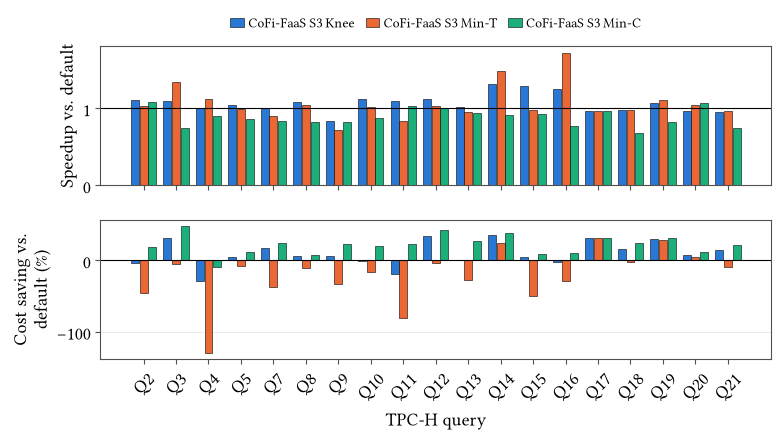

In [71]:
fig, axs = plt.subplots(2, 1, figsize=(8, 4.6), sharex=True)
w = 0.8 / len(VPLANS)
for i, p in enumerate(VPLANS):
    xs = np.arange(len(VQS)) + (i - (len(VPLANS) - 1) / 2) * w
    ok = [(q, p) in VI.index for q in VQS]
    sp = [VI.loc[(q, "default"), "T"] / VI.loc[(q, p), "T"] if o else np.nan for q, o in zip(VQS, ok)]
    sv = [100 * (1 - VI.loc[(q, p), "C"] / VI.loc[(q, "default"), "C"]) if o else np.nan for q, o in zip(VQS, ok)]
    axs[0].bar(xs, sp, w * 0.92, color=PLAN_COLOR[p], edgecolor="black", lw=0.4, label=PLAN_LABEL[p], zorder=2)
    axs[1].bar(xs, sv, w * 0.92, color=PLAN_COLOR[p], edgecolor="black", lw=0.4, zorder=2)
axs[0].axhline(1, color="black", lw=0.8); axs[1].axhline(0, color="black", lw=0.8)
axs[0].set_ylabel("Speedup vs. default"); axs[1].set_ylabel("Cost saving vs.\ndefault (%)")
axs[1].set_xticks(range(len(VQS)), [q.upper() for q in VQS], rotation=45)
axs[1].set_xlabel("TPC-H query")
for ax in axs:
    ax.grid(True, axis="y", color=style.GRID); ax.grid(False, axis="x"); ax.set_axisbelow(True)
axs[0].legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=FONT_SIZE - 3,
              handlelength=1.0, handletextpad=0.3, columnspacing=0.8)
fig.tight_layout()
style.save(fig, FIG, "e2e-validate-plans")
plt.show()

In [72]:
# estimate accuracy over all measured plans (incl. front_*, a plan aliased to another one counted once)
acc = V.dropna(subset=["T_est_s"]).merge(ALIAS[["query", "plan"]], how="left", indicator=True)
acc = acc[acc._merge == "left_only"].drop(columns="_merge")
summ = acc.groupby("plan").agg(queries=("query", "size"), T_meas=("T", "sum"), T_est=("T_est_s", "sum"),
                               C_meas=("C", "sum"), C_est=("C_est", "sum"),
                               MAPE_T=("err_T", lambda e: e.abs().mean()), MAPE_C=("err_C", lambda e: e.abs().mean()))
summ.loc["all"] = [len(acc), acc["T"].sum(), acc["T_est_s"].sum(), acc["C"].sum(), acc["C_est"].sum(),
                   acc["err_T"].abs().mean(), acc["err_C"].abs().mean()]
summ[["MAPE_T", "MAPE_C"]] = summ[["MAPE_T", "MAPE_C"]].map("{:.1%}".format)
summ.round(2)

,queries,T_meas,T_est,C_meas,C_est,MAPE_T,MAPE_C
plan,,,,,,,
default,19.0,306.91,283.14,53.85,51.63,17.3%,19.7%
front_02,18.0,285.32,214.76,49.88,48.84,20.6%,18.0%
front_03,17.0,295.79,232.47,47.15,43.98,17.7%,16.3%
front_04,18.0,312.94,263.75,46.21,41.24,16.1%,17.5%
front_05,18.0,324.97,289.24,44.98,39.96,15.8%,19.0%
knee,19.0,300.32,236.18,47.96,44.78,16.9%,17.8%
min_C,18.0,361.93,353.78,41.87,38.79,13.4%,17.3%
min_T,18.0,304.66,200.65,61.30,68.96,29.4%,23.3%
all,145.0,2492.85,2073.98,393.20,378.17,18.4%,18.6%


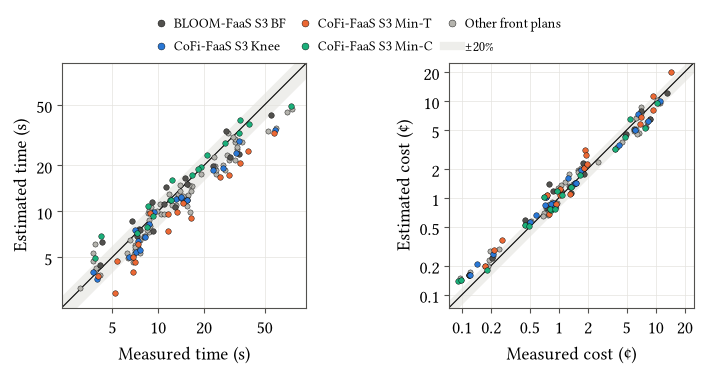

In [73]:
from matplotlib.ticker import FixedLocator, NullLocator, FuncFormatter
from matplotlib.lines import Line2D
# estimated vs. measured on log-log axes (the points spread over two orders of magnitude); band = ±BAND
ACC_LOG = True
BAND = 0.20
ACC_ORDER = ["default", "knee", "min_T", "min_C"]          # legend order; other plans drawn grey as "Other front plans"
NICE = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200]
fig, axs = plt.subplots(1, 2, figsize=(8, 3.4))
for ax, (m, e, lab) in zip(axs, [("T", "T_est_s", "time (s)"), ("C", "C_est", f"cost ({style.COST_UNIT})")]):
    other = acc[~acc.plan.isin(ACC_ORDER)]
    ax.scatter(other[m], other[e], s=14, color="#b5b4ae", edgecolor="black", lw=0.3, zorder=2)
    for p in ACC_ORDER:
        g = acc[acc.plan == p]
        ax.scatter(g[m], g[e], s=16, color=PLAN_COLOR[p], edgecolor="black", lw=0.3, zorder=3)
    vals = pd.concat([acc[m], acc[e]])
    lo, hi = (vals.min() * 0.8, vals.max() * 1.25) if ACC_LOG else (0, vals.max() * 1.05)
    xs = np.geomspace(lo, hi, 50) if ACC_LOG else np.linspace(lo, hi, 50)
    ax.plot(xs, xs, color="black", lw=0.8, zorder=1)
    ax.fill_between(xs, xs * (1 - BAND), xs * (1 + BAND), color=style.GRID, alpha=0.6, lw=0, zorder=0)
    if ACC_LOG:
        ax.set_xscale("log"); ax.set_yscale("log")
        ticks = [t for t in NICE if lo <= t <= hi]
        for axis in (ax.xaxis, ax.yaxis):
            axis.set_major_locator(FixedLocator(ticks)); axis.set_minor_locator(NullLocator())
            axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.grid(True, color=style.GRID); ax.set_axisbelow(True)
    ax.set_xlabel(f"Measured {lab}"); ax.set_ylabel(f"Estimated {lab}")
mk = lambda col: Line2D([], [], ls="", marker="o", ms=5, mfc=col, mec="black", mew=0.3)
h = [mk(PLAN_COLOR[p]) for p in ACC_ORDER] + [mk("#b5b4ae"), Line2D([], [], color=style.GRID, lw=6, alpha=0.6)]
l = [PLAN_LABEL[p] for p in ACC_ORDER] + ["Other front plans", f"±{BAND:.0%}"]
fig.legend(h, l, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.12), fontsize=FONT_SIZE - 3,
           handlelength=1.2, handletextpad=0.3, columnspacing=0.8)
fig.tight_layout()
style.save(fig, FIG, "e2e-validate-accuracy")
plt.show()

## Estimated vs. measured Pareto front

Each panel is the Pareto-front panel of section 3 (estimates): grey = every plan the optimizer evaluated, blue =
the estimated Pareto front, circle = the selected plan (knee), triangle / square = the min-time / min-cost plan.
The black dashed line is the **measured** Pareto front, with its own knee / min-time / min-cost plan drawn hollow
(same shapes; knee chosen like the optimizer's: closest to (T_min, C_min) after normalising): the plans run on the testbed (default, knee and the points
spread along the front; median of the runs) that no other measured plan beats in both time and cost (one dot when a single measured plan beats all the others).
First all 19 queries (to choose from), then the queries in `FRONT_QS` for the paper.

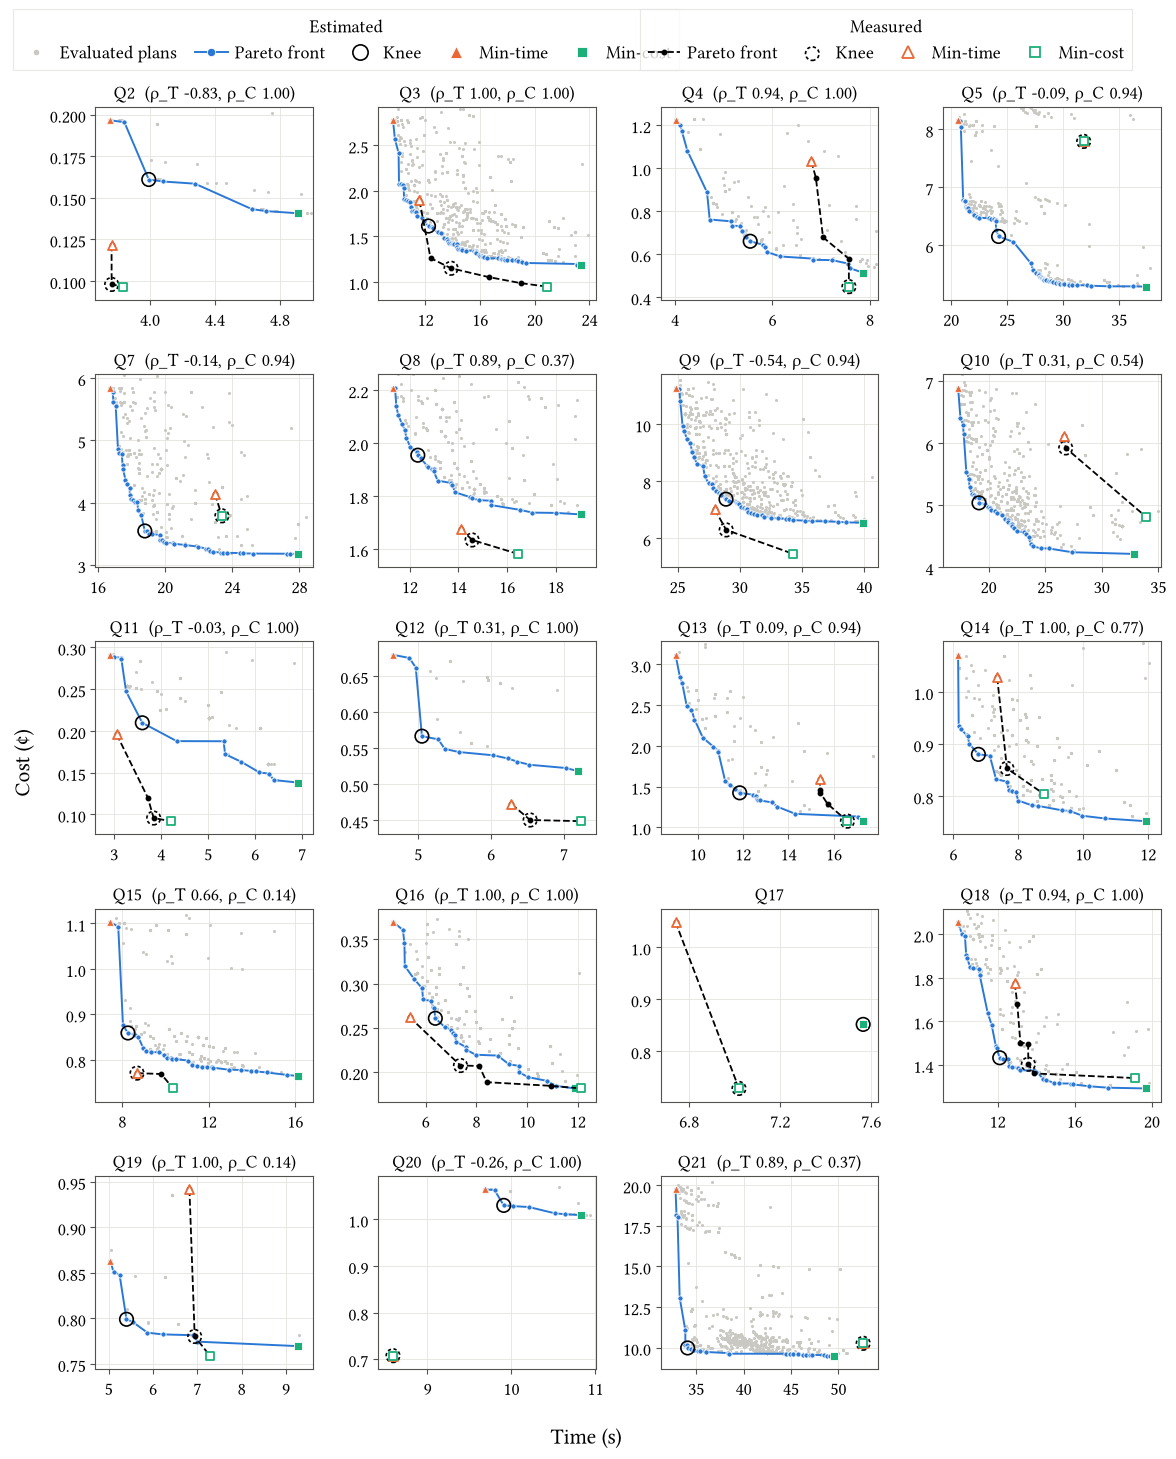

In [74]:
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
PTS = pd.read_csv(f"{DATA}/validate-points.csv")          # = section 3 data/points.csv
PTS["C"] = PTS["C"] * style.COST_SCALE
FRONT_PLANS = [f"front_{i:02d}" for i in range(1, 7)]
GRAY, BLUE, ORANGE, GREEN, MEAS = "#c9c8c2", "#2a78d6", "#eb6834", "#1baf7a", "#000000"   # section 3 colours
PAD = 0.08


def measured_front(q):
    """Measured plans of q (median T, C) that no other measured plan beats in both, sorted by T."""
    d = V[(V["query"] == q) & V["T_est_s"].notna()]
    d = d.assign(_o=d.plan.map({"default": 0, "knee": 1, "min_T": 2, "min_C": 3}).fillna(4)).sort_values("_o")
    d = d.drop_duplicates(subset=["T", "C"])                  # an aliased plan (front_01 = min_T, ...) once, by its name
    nd = [r for _, r in d.iterrows()
          if not any(o["T"] <= r["T"] and o["C"] <= r["C"] and (o["T"] < r["T"] or o["C"] < r["C"]) for _, o in d.iterrows())]
    return pd.DataFrame(nd).sort_values("T")


def front_ends(F):
    """min-T, knee, min-C of a front sorted by T; knee as in plan_opt.py: closest to (T_min, C_min) after normalising."""
    tmin, cmin = F["T"].min(), F["C"].min()
    knee = F.loc[((F["T"] / tmin - 1) ** 2 + (F["C"] / cmin - 1) ** 2).idxmin()]
    return F.iloc[0], knee, F.iloc[-1]


def rank_corr(q):
    """Spearman rho between estimated and measured T (and C) over the distinct front plans of q."""
    g = V[(V["query"] == q) & V.plan.isin(FRONT_PLANS)].drop_duplicates(subset=["T", "C"])
    if len(g) < 3:
        return np.nan, np.nan
    return g["T"].rank().corr(g["T_est_s"].rank()), g["C"].rank().corr(g["C_est"].rank())


def front_panel(ax, q, title_rho=False):
    R = PTS[PTS["query"] == q]
    F = R[R.pareto].sort_values("T")
    ax.scatter(R["T"], R["C"], s=5, color=GRAY, lw=0, rasterized=True)
    ax.plot(F["T"], F["C"], color=BLUE, lw=1.4, zorder=2)
    ax.scatter(F["T"], F["C"], s=14, color=BLUE, edgecolor="white", lw=0.6, zorder=3)
    k = VI.loc[(q, "knee")]
    ax.scatter([k["T_est_s"]], [k["C_est"]], s=95, facecolor="none", edgecolor="black", lw=1.2, zorder=4)
    for key, mk, col in (("min_T", "^", ORANGE), ("min_C", "s", GREEN)):
        p = VI.loc[(q, key)]
        ax.scatter([p["T_est_s"]], [p["C_est"]], marker=mk, s=30, color=col, edgecolor="white", lw=0.6, zorder=5)
    M = measured_front(q)
    ax.plot(M["T"], M["C"], color=MEAS, lw=1.3, ls="--", marker="o", ms=3.2, zorder=6)   # dots: a front of one plan stays visible
    mt, mk_, mc = front_ends(M)                                # measured min-T / knee / min-C: same shapes, hollow
    ax.scatter([mk_["T"]], [mk_["C"]], s=95, facecolor="none", edgecolor="black", lw=1.2, ls=(0, (2, 1.5)), zorder=7)
    ax.scatter([mt["T"]], [mt["C"]], marker="^", s=42, facecolor="white", edgecolor=ORANGE, lw=1.3, zorder=8)
    ax.scatter([mc["T"]], [mc["C"]], marker="s", s=36, facecolor="white", edgecolor=GREEN, lw=1.3, zorder=8)
    rt, rc = rank_corr(q)
    ax.set_title(q.upper() + (f"  (ρ_T {rt:.2f}, ρ_C {rc:.2f})" if title_rho and not np.isnan(rt) else ""),
                 fontsize=FONT_SIZE - (0 if title_rho else 0))
    ax.grid(True, color=style.GRID, lw=0.6); ax.set_axisbelow(True)
    for vals, setlim in ((pd.concat([F["T"], M["T"]]), ax.set_xlim), (pd.concat([F["C"], M["C"]]), ax.set_ylim)):
        lo, hi = vals.min(), vals.max()
        pad = (hi - lo) * PAD or lo * 0.05
        setlim(lo - pad, hi + pad)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, steps=[1, 2, 4, 5, 10], min_n_ticks=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, steps=[1, 2, 2.5, 5, 10], min_n_ticks=3))


def front_legend(fig, est, meas):
    """Two legend boxes, estimated and measured. est / meas: dict(x, y, ncol, loc, fontsize), (x, y) in figure
    coordinates (0..1), `loc` = the corner of the box placed at (x, y)."""
    mk = lambda m, ms, fc, ec="white", mew=0.6: Line2D([], [], ls="", marker=m, ms=ms, mfc=fc, mec=ec, mew=mew)
    boxes = [
        ("Estimated", est,
         [mk("o", 4, GRAY, GRAY, 0), Line2D([], [], color=BLUE, lw=1.4, marker="o", ms=6, mfc=BLUE, mec="white", mew=0.6),
          mk("o", 11, "none", "black", 1.2), mk("^", 8, ORANGE), mk("s", 7, GREEN)],
         ["Evaluated plans", "Pareto front", "Knee", "Min-time", "Min-cost"]),
        ("Measured", meas,
         [Line2D([], [], color=MEAS, lw=1.3, ls="--", marker="o", ms=3.2),
          fig.axes[0].scatter([], [], s=95, facecolor="none", edgecolor="black", lw=1.2, ls=(0, (2, 1.5))),   # dashed circle
          mk("^", 8, "white", ORANGE, 1.3), mk("s", 7, "white", GREEN, 1.3)],
         ["Pareto front", "Knee", "Min-time", "Min-cost"]),
    ]
    for title, pos, h, l in boxes:
        pos = {"ncol": 3, "loc": "upper center", "fontsize": FONT_SIZE , **pos}
        leg = fig.legend(h, l, loc=pos["loc"], ncol=pos["ncol"], bbox_to_anchor=(pos["x"], pos["y"]), fontsize=pos["fontsize"],
                         title=title, title_fontsize=pos["fontsize"], frameon=True, fancybox=False, edgecolor=style.GRID,
                         handlelength=1.8, handletextpad=0.4, columnspacing=1.0, labelspacing=0.3, borderpad=0.4)
        leg.get_frame().set_linewidth(0.8)


# all queries, to choose the ones for the paper (title: rank correlation of the front plans, estimated vs. measured)
# legend of the 19-query figure: anchor (x, y) in figure coordinates, columns
ALL_LEGEND = dict(est=dict(x=0.3, y=1.045, ncol=5), meas=dict(x=0.75, y=1.045, ncol=4))
ALL_QS = sorted(V["query"].unique(), key=qnum)
fig, axs = plt.subplots(5, 4, figsize=(12, 14))
for ax, q in zip(axs.flat, ALL_QS):
    front_panel(ax, q, title_rho=True)
    ax.tick_params(labelsize=FONT_SIZE)
for ax in axs.flat[len(ALL_QS):]:
    ax.axis("off")
fig.supxlabel("Time (s)"); fig.supylabel(f"Cost ({style.COST_UNIT})")
front_legend(fig, **ALL_LEGEND)
fig.tight_layout()
style.save(fig, FIG, "e2e-validate-front-all")
plt.show()

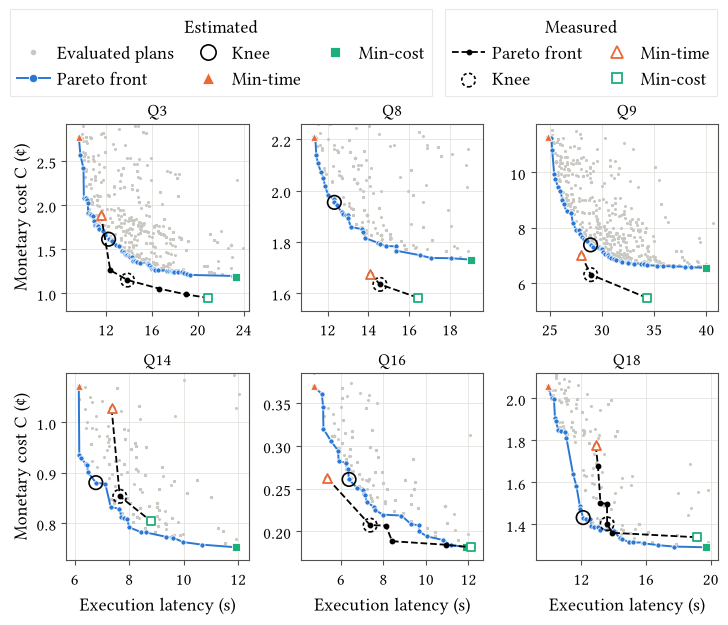

In [75]:
FRONT_QS = ["q3", "q8", "q9", "q14", "q16", "q18"]     # the queries shown in the paper figure
# legend: two boxes, adjust here:
#   x, y   anchor in figure coordinates (0..1; y > 1 = above the panels), loc = which corner of the box sits at (x, y)
#   ncol   columns (estimated: 5 entries, measured: 4)
LEGEND_EST = dict(x=0.3, y=1.0, ncol=3, loc="upper center", fontsize=FONT_SIZE )
LEGEND_MEAS = dict(x=0.8, y=1.0, ncol=2, loc="upper center", fontsize=FONT_SIZE )
LEGEND_TOP = 0.95    # room kept above the panels for the legends (inches); 0 when they are inside / beside the panels
# font sizes of this figure (FONT_SIZE = 13 from cofi/style.py)
LABEL_SIZE = FONT_SIZE        # axis titles (x: latency, y: cost)
TICK_SIZE = FONT_SIZE - 1     # numbers on the axes
TITLE_SIZE = FONT_SIZE - 1    # panel titles Q3, Q9, ...
ncol = 3
nrow = -(-len(FRONT_QS) // ncol)
height = 2.6 * nrow + 0.05 + LEGEND_TOP
fig, axs = plt.subplots(nrow, ncol, figsize=(7.2, height), squeeze=False)
for ax, q in zip(axs.flat, FRONT_QS):
    front_panel(ax, q)
    ax.tick_params(labelsize=TICK_SIZE)
    ax.title.set_fontsize(TITLE_SIZE)
for ax in list(axs.flat)[len(FRONT_QS):]:
    ax.axis("off")
for ax in axs[-1]: ax.set_xlabel("Execution latency (s)", fontsize=LABEL_SIZE)
for ax in axs[:, 0]: ax.set_ylabel(f"Monetary cost C ({style.COST_UNIT})", fontsize=LABEL_SIZE)
front_legend(fig, LEGEND_EST, LEGEND_MEAS)
fig.tight_layout(pad=0.3, w_pad=0.8, h_pad=0.6, rect=(0, 0, 1, 1 - LEGEND_TOP / height))
style.save(fig, FIG, "e2e-validate-front")
plt.show()

In [76]:
# per query: which plan is knee / min-T / min-C on the estimated front, and which one on the measured front
rows = []
for q in ALL_QS:
    M = measured_front(q)
    mt, mk_, mc = front_ends(M)
    rows.append({"query": q.upper(), "knee meas": mk_["plan"], "min_T meas": mt["plan"], "min_C meas": mc["plan"],
                 "knee T meas/est knee": VI.loc[(q, "knee"), "T"] / mk_["T"], "knee C meas/est knee": VI.loc[(q, "knee"), "C"] / mk_["C"]})
KN = pd.DataFrame(rows).set_index("query")
print("estimated knee = measured knee:", (KN["knee meas"] == "knee").sum(), "of", len(KN),
      "| min_T:", (KN["min_T meas"] == "min_T").sum(), "| min_C:", (KN["min_C meas"] == "min_C").sum())
KN.round(2)

estimated knee = measured knee: 2 of 19 | min_T: 5 | min_C: 10


,knee meas,min_T meas,min_C meas,knee T meas/est knee,knee C meas/est knee
query,,,,,
Q2,front_05,knee,min_C,1.00,1.24
Q3,front_03,min_T,min_C,1.02,1.08
Q4,default,min_T,default,1.00,1.29
Q5,front_05,front_05,front_05,1.01,1.08
Q7,front_05,knee,front_05,0.98,1.09
Q8,front_03,knee,front_04,0.97,1.03
Q9,front_05,default,min_C,1.17,1.05
Q10,front_03,knee,min_C,0.99,1.03
Q11,front_05,front_02,min_C,1.03,1.48
